![](../img/330-banner.png)

# Lecture 13: Feature engineering and feature selection 

UBC 2025-26

## Imports

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as npr
import pandas as pd
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
    make_column_transformer,
)
sys.path.append(os.path.join(os.path.abspath(".."), "code"))
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
DATA_DIR = os.path.join(os.path.abspath(".."), "data/")
from sklearn.svm import SVC

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## Learning outcomes 

From this lecture, students are expected to be able to:

- Explain what feature engineering is and the importance of feature engineering in building machine learning models.  
- Carry out preliminary feature engineering on numeric data. 
- Explain the general concept of feature selection. 
- Discuss and compare different feature selection methods at a high level. 
- Use `sklearn`'s implementation of model-based selection and recursive feature elimination (`RFE`)

## Feature engineering: Motivation

## ❓❓ Questions for you

### iClicker Exercise 13.1 

**Select the most accurate option below.**

Suppose you are working on a machine learning project. If you have to prioritize one of the following in your project which of the following would it be? 

- (A) The quality and size of the data 
- (B) Most recent deep neural network model 
- (C) Most recent optimization algorithm

### Garbage in, garbage out.

- Model building is interesting. But in your machine learning projects, you'll be spending more than half of your time on data preparation, feature engineering, and transformations.
- The _quality_ of the data is important. Your model is only as good as your data. 

### What is feature engineering?  

- Better features: more flexibility, higher score, we can get by with simple and more interpretable models. 
- If your features, i.e., representation is bad, whatever fancier model you build is not going to help.

<blockquote>
<b>Feature engineering</b> is the process of transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model accuracy on unseen data.<br> 
- Jason Brownlee    
</blockquote>    



### Some quotes on feature engineering 

A quote by Pedro Domingos [A Few Useful Things to Know About Machine Learning](https://homes.cs.washington.edu/~pedrod/papers/cacm12.pdf)

<blockquote>
... At the end of the day, some machine learning projects succeed and some fail. What makes the difference? Easily the most important factor is the features used. 
</blockquote>


A quote by Andrew Ng, [Machine Learning and AI via Brain simulations](https://ai.stanford.edu/~ang/slides/DeepLearning-Mar2013.pptx)

<blockquote>
Coming up with features is difficult, time-consuming, requires expert knowledge. "Applied machine learning" is basically feature engineering.
</blockquote>

### Better features usually help more than a better model.
- Good features would ideally:
    - capture **most important aspects** of the problem
    - allow learning with **few examples**
    - **generalize** to new scenarios.
<br>

- There is a trade-off between **simple** and **expressive** features:
    - With **simple features** overfitting risk is low, but **scores might be low**.
    - With **complicated features** scores can be high, but so is **overfitting risk**.

#### Domain-specific transformations

In some domains there are natural transformations to do:
- Spectrograms (sound data)
- Wavelets (image data)
- Convolutions 

![](../img/spectogram.png)

<!-- <img src="img/spectogram.png" width="800" height="800"> -->

[Source](https://en.wikipedia.org/wiki/Spectrogram)

<br><br><br><br>

### Feature interactions and feature crosses

- A **feature cross** is a synthetic feature formed by multiplying or crossing two or more features. 
- Example: 
Is the following dataset (XOR function) linearly separable?  

| $$x_1$$ | $$x_2$$ | target|
|---------|---------|---------|
| 1 | 1  | 0|
| -1 | 1  | 1|
| 1 | -1  | 1|
| -1 | -1  | 0|    


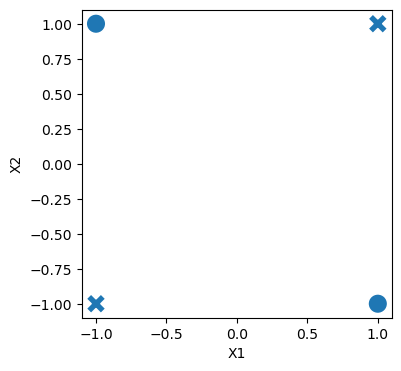

In [2]:
import seaborn as sb
X = np.array([
    [-1, -1],
    [1, -1],
    [-1, 1],
    [1, 1]
])
y = np.array([1, 0, 0, 1])
df = pd.DataFrame(np.column_stack([X, y]), columns=["X1", "X2", "target"])
plt.figure(figsize=(4, 4))
sb.scatterplot(data=df, x="X1", y="X2", style="target", s=200, legend=False);

- For XOR like problems, if we create a feature cross $x1x2$, the data becomes linearly separable. 

| $$x_1$$ | $$x_2$$ | $$x_1x_2$$ | target|
|---------|---------|---------|---------|
| 1 | 1  | 1 | 0|
| -1 | 1  | -1 | 1|
| 1 | -1  | -1 | 1|
| -1 | -1  | 1 | 0|    

In [3]:
df["X1X2"] = df["X1"] * df["X2"]
df

,X1,X2,target,X1X2
0,-1,-1,1,1
1,1,-1,0,-1
2,-1,1,0,-1
3,1,1,1,1


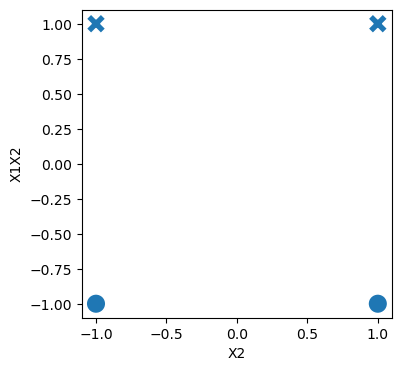

In [4]:
plt.figure(figsize=(4, 4))
sb.scatterplot(data=df, x="X2", y="X1X2", style="target", s=200, legend=False);

Let's look at an example with more data points. 

In [5]:
rng = np.random.RandomState(0)
rng.randn(4, 2)  # example output

array([[ 1.76405235,  0.40015721],
       [ 0.97873798,  2.2408932 ],
       [ 1.86755799, -0.97727788],
       [ 0.95008842, -0.15135721]])

In [6]:
# xx, yy = np.meshgrid(np.linspace(-3, 3, 50), np.linspace(-3, 3, 50))
rng = np.random.RandomState(0)
X_xor = rng.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
# Interaction term
X1X2 = X_xor[:, 0] * X_xor[:, 1]

In [7]:
df = pd.DataFrame({'X1': X_xor[:, 0], 'X2': X_xor[:, 1], 'X1X2': X1X2, 'Class': y_xor})
df.head()

,X1,X2,X1X2,Class
0,1.764052,0.400157,0.705898,False
1,0.978738,2.240893,2.193247,False
2,1.867558,-0.977278,-1.825123,True
3,0.950088,-0.151357,-0.143803,True
4,-0.103219,0.410599,-0.042382,True


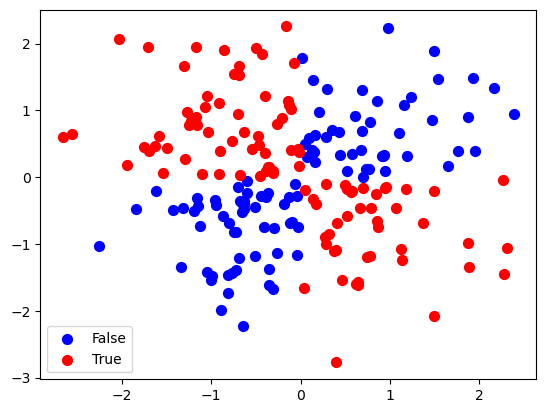

In [8]:
plt.scatter(df[df['Class'] == False]['X1'], df[df['Class'] == False]['X2'], c='blue', label='False', s=50)
plt.scatter(df[df['Class'] == True]['X1'], df[df['Class'] == True]['X2'], c='red', label='True', s=50)
plt.legend(loc='lower left')

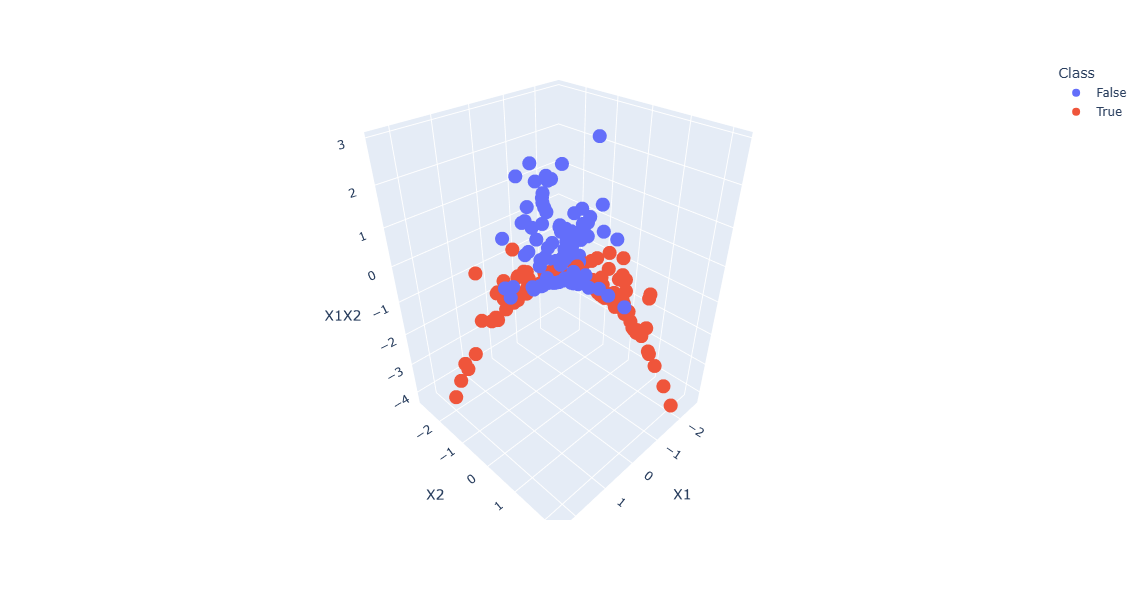

In [9]:
# Create an interactive 3D scatter plot using plotly
import plotly.express as px
fig = px.scatter_3d(df, x='X1', y='X2', z='X1X2', color='Class', color_continuous_scale=['blue', 'red'])
fig.update_layout(height=600)
fig.show()

In [10]:
LogisticRegression().fit(X_xor, y_xor).score(X_xor, y_xor)

0.535

In [11]:
from sklearn.preprocessing import PolynomialFeatures
pipe_xor = make_pipeline(
    PolynomialFeatures(interaction_only=True, include_bias=False), LogisticRegression()
)
pipe_xor.fit(X_xor, y_xor)
pipe_xor.score(X_xor, y_xor)

0.995

In [12]:
feature_names = (
    pipe_xor.named_steps["polynomialfeatures"].get_feature_names_out().tolist()
)

In [13]:
# transformed = pipe_xor.named_steps["polynomialfeatures"].transform(X_xor)

In [14]:
pd.DataFrame(
    pipe_xor.named_steps["logisticregression"].coef_.transpose(),
    index=feature_names,
    columns=["Feature coefficient"],
)

,Feature coefficient
x0,-0.028672
x1,0.129459
x0 x1,-5.086461


The interaction feature has the biggest coefficient! 

### Feature crosses for one-hot encoded features
- You can think of feature crosses of one-hot-features as logical conjunctions
- Suppose you want to **predict whether you will find parking** or not based on two features: 
    - **area** (possible categories: **UBC campus** and **Rogers Arena**)
    - **time** of the day (possible categories: **9am** and **7pm**)
- A feature cross in this case would create four new features: 
    - UBC campus and 9am
    - UBC campus and 7pm
    - Rogers Arena and 9am
    - Rogers Arena and 7pm. 
- The features UBC campus and 9am on their own are not that informative but the newly created feature UBC campus and 9am or Rogers Arena and 7pm would be quite informative.
- Coming up with the right combination of features requires some domain knowledge or careful examination of the data.  

### Feature crosses for one-hot encoded features
- You can think of **feature crosses of one-hot-features as logical conjunctions**
- Suppose you want to predict whether you will **find parking or not** based on two features: 
    - **area** (possible categories: UBC campus and Rogers Arena)
    - **time** of the day (possible categories: 9am and 7pm)
- A **feature cross** in this case would create **four new features**: 
    - UBC campus and 9am
    - UBC campus and 7pm
    - Rogers Arena and 9am
    - Rogers Arena and 7pm. 
- The features UBC campus and 9am on their own are not that informative but the newly created feature UBC campus and 9am or Rogers Arena and 7pm would be quite informative.
<br>

- Coming up with the **right combination** of features **requires** some **domain knowledge** or careful **examination of the data**. 

<br><br>

### Demo of feature engineering with numeric features

- Remember the [California housing dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices) we used earlier in the course? 
- The prediction task is predicting `median_house_value` for a given area. 

In [15]:
housing_df = pd.read_csv(DATA_DIR + "california_housing.csv")
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [16]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Suppose we decide to train `ridge` model on this dataset. 

- What would happen if you train a model without applying any transformation on the categorical features ocean_proximity? 
    - Error!! A linear model requires all features in a numeric form.  
- What would happen if we apply OHE on `ocean_proximity` but we do not scale the features?
    - No syntax error. But the model results are likely to be poor. 
- Do we need to apply any other transformations on this data?     

In this section, we will look into some common ways to do **feature engineering** for **numeric** or **categorical** features.

In [17]:
train_df, test_df = train_test_split(housing_df, test_size=0.2, random_state=123)

We have total rooms and the number of households in the neighbourhood. How about **creating rooms_per_household feature** using this information?

In [18]:
train_df = train_df.assign(
    rooms_per_household=train_df["total_rooms"] / train_df["households"]
)
test_df = test_df.assign(
    rooms_per_household=test_df["total_rooms"] / test_df["households"]
)

In [19]:
train_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household
9950,-122.33,38.38,28.0,1020.0,169.0,504.0,164.0,4.5694,287500.0,INLAND,6.219512
3547,-118.60,34.26,18.0,6154.0,1070.0,3010.0,1034.0,5.6392,271500.0,<1H OCEAN,5.951644
4448,-118.21,34.07,47.0,1346.0,383.0,1452.0,371.0,1.7292,191700.0,<1H OCEAN,3.628032
6984,-118.02,33.96,36.0,2071.0,398.0,988.0,404.0,4.6226,219700.0,<1H OCEAN,5.126238
4432,-118.20,34.08,49.0,1320.0,309.0,1405.0,328.0,2.4375,114000.0,<1H OCEAN,4.024390
...,...,...,...,...,...,...,...,...,...,...,...
7763,-118.10,33.91,36.0,726.0,NaN,490.0,130.0,3.6389,167600.0,<1H OCEAN,5.584615
15377,-117.24,33.37,14.0,4687.0,793.0,2436.0,779.0,4.5391,180900.0,<1H OCEAN,6.016688
17730,-121.76,37.33,5.0,4153.0,719.0,2435.0,697.0,5.6306,286200.0,<1H OCEAN,5.958393
15725,-122.44,37.78,44.0,1545.0,334.0,561.0,326.0,3.8750,412500.0,NEAR BAY,4.739264


**Let's start simple**. Imagine that we only three features: `longitude`, `latitude`, and our newly created `rooms_per_household` feature. 

In [20]:
X_train_housing = train_df[["latitude", "longitude", "rooms_per_household"]]
y_train_housing = train_df["median_house_value"]

In [21]:
from sklearn.compose import make_column_transformer

numeric_feats = ["latitude", "longitude", "rooms_per_household"]

preprocessor1 = make_column_transformer(
    (make_pipeline(SimpleImputer(), StandardScaler()), numeric_feats)
)

In [22]:
lr_1 = make_pipeline(preprocessor1, Ridge())
pd.DataFrame(
    cross_validate(lr_1, X_train_housing, y_train_housing, return_train_score=True)
)

,fit_time,score_time,test_score,train_score
0,0.018919,0.008491,0.280028,0.311769
1,0.010729,0.004443,0.325319,0.300464
2,0.010592,0.005046,0.317277,0.301952
3,0.019866,0.004990,0.316798,0.303004
4,0.010049,0.004401,0.260258,0.314840


- The scores are not great. 
- Let's look at the distribution of the longitude and latitude features. 

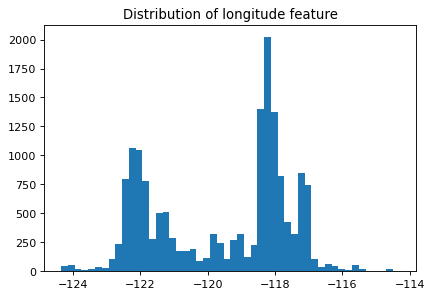

In [23]:
plt.figure(figsize=(6, 4), dpi=80)
plt.hist(train_df["longitude"], bins=50)
plt.title("Distribution of longitude feature");

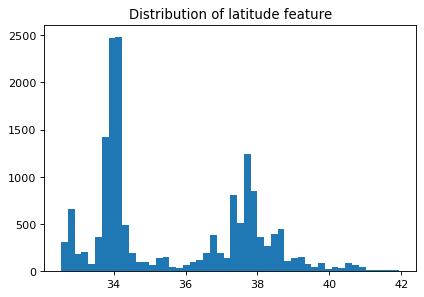

In [24]:
plt.figure(figsize=(6, 4), dpi=80)
plt.hist(train_df["latitude"], bins=50)
plt.title("Distribution of latitude feature");

- Remember that **linear models can capture only linear relationships**.
-  What if the relationship is **not linear?**
- How about **discretizing latitude and longitude** features and putting them into buckets?
- This process of transforming numeric features into categorical features is **called bucketing or binning**.
- In `sklearn` you can do this using `KBinsDiscretizer` transformer. 
- Let's examine whether we get better results with binning.

In [25]:
from sklearn.preprocessing import KBinsDiscretizer

discretization_feats = ["latitude", "longitude"]
numeric_feats = ["rooms_per_household"]

preprocessor2 = make_column_transformer(
    (make_pipeline(SimpleImputer(), StandardScaler()), numeric_feats),
    (KBinsDiscretizer(n_bins=20, encode="onehot"), discretization_feats),
)

In [26]:
lr_2 = make_pipeline(preprocessor2, Ridge())
pd.DataFrame(
    cross_validate(lr_2, X_train_housing, y_train_housing, return_train_score=True)
)

,fit_time,score_time,test_score,train_score
0,0.040230,0.008652,0.441445,0.456419
1,0.024217,0.009331,0.469571,0.446216
2,0.039242,0.014552,0.479132,0.446869
3,0.027315,0.006292,0.450822,0.453367
4,0.029161,0.008676,0.388169,0.467628


The results are better with binned features. Let's examine what do these binned features look like. 

In [27]:
lr_2.fit(X_train_housing, y_train_housing)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...), ('kbinsdiscretizer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

In [28]:
pd.DataFrame(
    preprocessor2.fit_transform(X_train_housing).todense(),
    columns=preprocessor2.get_feature_names_out(),
)

,pipeline__rooms_per_household,kbinsdiscretizer__latitude_0.0,kbinsdiscretizer__latitude_1.0,kbinsdiscretizer__latitude_2.0,kbinsdiscretizer__latitude_3.0,kbinsdiscretizer__latitude_4.0,kbinsdiscretizer__latitude_5.0,kbinsdiscretizer__latitude_6.0,kbinsdiscretizer__latitude_7.0,kbinsdiscretizer__latitude_8.0,...,kbinsdiscretizer__longitude_10.0,kbinsdiscretizer__longitude_11.0,kbinsdiscretizer__longitude_12.0,kbinsdiscretizer__longitude_13.0,kbinsdiscretizer__longitude_14.0,kbinsdiscretizer__longitude_15.0,kbinsdiscretizer__longitude_16.0,kbinsdiscretizer__longitude_17.0,kbinsdiscretizer__longitude_18.0,kbinsdiscretizer__longitude_19.0
0,0.316164,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.209903,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.711852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.117528,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.554621,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,0.064307,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
16508,0.235706,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16509,0.212581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16510,-0.271037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


How about discretizing all three features? 

In [29]:
from sklearn.preprocessing import KBinsDiscretizer

discretization_feats = ["latitude", "longitude", "rooms_per_household"]

preprocessor3 = make_column_transformer(
    (KBinsDiscretizer(n_bins=20, encode="onehot"), discretization_feats),
)

In [30]:
lr_3 = make_pipeline(preprocessor3, Ridge())
pd.DataFrame(
    cross_validate(lr_3, X_train_housing, y_train_housing, return_train_score=True)
)

,fit_time,score_time,test_score,train_score
0,0.026128,0.008324,0.590618,0.571969
1,0.025553,0.006864,0.575907,0.570473
2,0.025957,0.005935,0.579091,0.573542
3,0.028708,0.006719,0.571500,0.574260
4,0.026068,0.007039,0.541488,0.581687


- The results have improved further!! 
- Let's examine the coefficients

In [31]:
lr_3.fit(X_train_housing, y_train_housing)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('kbinsdiscretizer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [32]:
feature_names = (
    lr_3.named_steps["columntransformer"]
    .named_transformers_["kbinsdiscretizer"]
    .get_feature_names_out()
)

In [33]:
lr_3.named_steps["ridge"].coef_.shape

(60,)

In [34]:
coefs_df = pd.DataFrame(
    lr_3.named_steps["ridge"].coef_.transpose(),
    index=feature_names,
    columns=["coefficient"],
).sort_values("coefficient", ascending=False)
coefs_df.head(10)

,coefficient
longitude_1.0,211343.036136
latitude_1.0,205059.296601
latitude_0.0,201862.534342
longitude_0.0,190319.721818
longitude_2.0,160282.191204
longitude_3.0,157234.920305
latitude_2.0,154105.963689
rooms_per_household_19.0,138503.477291
latitude_8.0,135299.516394
longitude_4.0,132292.924485


- Does it make sense to take feature crosses in this context?
- What information would they encode? 

<br><br>

### Demo of feature engineering for text data 

Check out [a demo](13_feature-engineering-selection-demo.ipynb) of feature engineering on text data.

<br><br>

### Interim summary 

- Feature engineering is finding the useful representation of the data that can help us effectively solve our problem.
- For **numeric data**, some common operations to create new features are: 
    - **Discretization**: Converting continuous data into discrete buckets. For example, age could be split into categories like 0-20, 21-40, etc. to learn non-linear relationships 
    - **Interaction Features**: Creating new features by combining two or more existing features. 
- In the context of **text data**, if we want to go beyond bag-of-words and incorporate human knowledge in models, we carry out feature engineering. Some common features include:
    - **ngram** features
    - **part-of-speech** features
    - **named entit**y features
    - **emoticons** in text
- These are usually extracted from pre-trained models using libraries such as `spaCy` (see the demo above).
- Now a lot of this, especially in the context of text and images, has moved to deep learning.
- Despite the rise of deep learning, many industries still rely on manual feature engineering. 

<br><br>

- The best features are application-dependent.
- It's hard to give general advice. But here are some guidelines. 
    - Ask the domain experts.
    - Go through academic papers in the discipline. 
    - Often have idea of right discretization/standardization/transformation.
    - If no domain expert, cross-validation will help.
- If you have lots of data, use deep learning methods. 

<blockquote>
    The algorithms we used are very standard for Kagglers ... We spent most of our efforts in feature engineering... <br>
- Xavier Conort, on winning the Flight Quest challenge on Kaggle    
</blockquote>    

<br><br><br><br>

## Feature selection: Introduction and motivation 


- With so many ways to add new features, we can increase dimensionality of the data. 
- More features means more complex models, which means increasing the chance of overfitting. 


### What is feature selection?

- Find the features	(columns) $X$ that are important for predicting	$y$, and remove the features that aren't. 

- Given $X = \begin{bmatrix}x_1 & x_2 & \dots & x_n\\  \\  \\  \end{bmatrix}$ and $y = \begin{bmatrix}\\  \\  \\  \end{bmatrix}$, find the columns $1 \leq j \leq n$ in $X$ that are important for predicting $y$.


### Why feature selection?

- **Interpretability**: Models are more interpretable with fewer features. If you get the same performance with 10 features instead of 500 features, why not use the model with smaller number of features?
- **Computation**: Models fit/predict faster with fewer columns.
- **Data collection**: What type of new data should I collect? It may be cheaper to collect fewer columns.
- **Fundamental tradeoff**: Can I reduce overfitting by removing useless features?

Feature selection can often result in better performing (less overfit), easier to understand, and faster model.

### **How** do we carry out feature selection? 

- There are a number of ways. 
- You could use **domain knowledge** to **discard** features. 
- We are briefly going to look at some **automatic feature selection** methods from `sklearn`: 
    - Model-based selection 
    - Recursive feature elimination
    - Forward selection 
- Very **related** to looking at **feature importances**.

In [35]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0, test_size=0.5
)

In [36]:
X_train.shape

(284, 30)

In [37]:
pipe_lr_all_feats = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pipe_lr_all_feats.fit(X_train, y_train)
pd.DataFrame(
    cross_validate(pipe_lr_all_feats, X_train, y_train, return_train_score=True)
).mean()

fit_time       0.004283
score_time     0.000999
test_score     0.968233
train_score    0.987681
dtype: float64

### Model-based selection

- Use a supervised machine learning **model to judge the importance** of each feature.
- Keep only the most important ones. 
- Supervised machine learning **model used for feature selection** can be **different** that the one used as the **final estimator**. 
- Use a model which has some way to calculate feature importances.

- To use model-based selection, we use `SelectFromModel` transformer.
- It **selects** features which have the **feature importances greater** than the provided **threshold**.
- Below I'm using `RandomForestClassifier` for feature selection with threahold "median" of feature importances. 
- Approximately how many features will be selected? 

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

select_rf = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42), 
    threshold="median"
)

Can we use KNN to select features?

In [39]:
from sklearn.neighbors import KNeighborsClassifier
select_knn = SelectFromModel(
    KNeighborsClassifier(), 
    threshold="median"
)

pipe_lr_model_based = make_pipeline(
    StandardScaler(), select_knn, LogisticRegression(max_iter=1000)
)

#pd.DataFrame(
#    cross_validate(pipe_lr_model_based, X_train, y_train, return_train_score=True)#
#).mean()

**No** KNN won't work since it does **not report feature importances**.

What about SVC?

In [40]:
select_svc = SelectFromModel(
    SVC(), threshold="median"
)

pipe_lr_model_based = make_pipeline(
    StandardScaler(), select_svc, LogisticRegression(max_iter=1000)
)

# pd.DataFrame(
#    cross_validate(pipe_lr_model_based, X_train, y_train, return_train_score=True)
# ).mean()

Only with a linear kernel but **not with RBF kernel**.

We can put the **feature selection transformer** in a pipeline. 

In [41]:
pipe_lr_model_based = make_pipeline(
    StandardScaler(), select_rf, LogisticRegression(max_iter=1000)
)

pd.DataFrame(
    cross_validate(pipe_lr_model_based, X_train, y_train, return_train_score=True)
).mean()

fit_time       0.185070
score_time     0.017248
test_score     0.950564
train_score    0.974480
dtype: float64

In [42]:
pipe_lr_model_based.fit(X_train, y_train)
pipe_lr_model_based.named_steps["selectfrommodel"].transform(X_train).shape

(284, 15)

Similar results with **only 15 features** instead of 30 features. 

<br><br>

### Recursive feature elimination (RFE)

- Build a series of models
- **At each iteration, discard the least important feature** according to the model. 
- Computationally expensive
- Basic idea
    - fit model
    - find least important feature
    - remove
    - iterate.

### RFE algorithm 

1. Decide $k$, the number of features to select. 
2. Assign importances to features, e.g. by fitting a model and looking at `coef_` or `feature_importances_`.
3. Remove the least important feature.
4. Repeat steps 2-3 until only $k$ features are remaining.

Note that, because of changes in feature interactions, this is **not** the same as just removing all the less important features in one shot!

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [44]:
from sklearn.feature_selection import RFE

# create ranking of features
rfe = RFE(LogisticRegression(), n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)
rfe.ranking_

array([16, 12, 19, 13, 23, 20, 10,  1,  9, 22,  2, 25,  5,  7, 15,  4, 26,
       18, 21,  8,  1,  1,  1,  6, 14, 24,  3,  1, 17, 11])

In [45]:
print(rfe.support_)

[False False False False False False False  True False False False False
 False False False False False False False False  True  True  True False
 False False False  True False False]


In [46]:
print("selected features: ", cancer.feature_names[rfe.support_])

selected features:  ['mean concave points' 'worst radius' 'worst texture' 'worst perimeter'
 'worst concave points']


In [47]:
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

- How do we know what value to pass to `n_features_to_select`?

- Use `RFECV` which uses cross-validation to select number of features. 

In [48]:
from sklearn.feature_selection import RFECV

rfe_cv = RFECV(LogisticRegression(max_iter=2000), cv=10)
rfe_cv.fit(X_train_scaled, y_train)
print('Best value for n_features_to_select:', sum(rfe_cv.support_))
print(rfe_cv.support_)
print(cancer.feature_names[rfe_cv.support_])

Best value for n_features_to_select: 17
[False  True False  True False False  True  True  True False  True False
  True  True False  True False False False  True  True  True  True  True
 False False  True  True False  True]
['mean texture' 'mean area' 'mean concavity' 'mean concave points'
 'mean symmetry' 'radius error' 'perimeter error' 'area error'
 'compactness error' 'fractal dimension error' 'worst radius'
 'worst texture' 'worst perimeter' 'worst area' 'worst concavity'
 'worst concave points' 'worst fractal dimension']


In [49]:
rfe_pipe = make_pipeline(
    StandardScaler(),
    RFECV(LogisticRegression(max_iter=2000), cv=10),
    RandomForestClassifier(n_estimators=100, random_state=42),
)

pd.DataFrame(cross_validate(rfe_pipe, X_train, y_train, return_train_score=True)).mean()

fit_time       1.144889
score_time     0.009675
test_score     0.943609
train_score    1.000000
dtype: float64

- Slow because there is cross validation within cross validation 
- Not a big improvement in scores compared to all features on this toy case

<br><br>

## (Optional) Search and score

- Define a **scoring function** $f(S)$ that measures the quality of the **set of features** $S$.
- Now **search** for the set of features $S$ with the **best score**.

### General idea of search and score methods 

- Example: Suppose you have three features: $A, B, C$
    - Compute **score** for $S = \{\}$
    - Compute **score** for $S = \{A\}$
    - Compute **score** for $S= \{B\}$
    - Compute **score** for $S = \{C\}$
    - Compute **score** for $S = \{A,B\}$    
    - Compute **score** for $S = \{A,C\}$
    - Compute **score** for $S = \{B,C\}$
    - Compute **score** for $S = \{A,B,C\}$    
- Return $S$ with the best score.  
- How many distinct combinations we have to try out? 

### (Optional) Forward or backward selection 

- Also called wrapper methods
- Shrink or grow feature set by removing or adding one feature at a time 
- Makes the decision based on whether adding/removing the feature improves the CV score or not

![](../img/forward_selection.png)

<!-- <img src='img/forward_selection.png' width="1000" height="1000" /> -->

In [50]:
# from sklearn.feature_selection import SequentialFeatureSelector

# pipe_forward = make_pipeline(
#     StandardScaler(),
#     SequentialFeatureSelector(LogisticRegression(max_iter=1000), 
#                               direction="forward", 
#                               n_features_to_select='auto', 
#                               tol=None),
#     RandomForestClassifier(n_estimators=100, random_state=42),
# )
# pd.DataFrame(
#     cross_validate(pipe_forward, X_train, y_train, return_train_score=True)
# ).mean()

In [51]:
# pipe_forward = make_pipeline(
#     StandardScaler(),
#     SequentialFeatureSelector(
#         LogisticRegression(max_iter=1000), 
#                            direction="backward", 
#                            n_features_to_select=15),
#     RandomForestClassifier(n_estimators=100, random_state=42),
# )
# pd.DataFrame(
#     cross_validate(pipe_forward, X_train, y_train, return_train_score=True)
# ).mean()

### Other ways to search 

- Stochastic local search
    - Inject randomness so that we can explore new parts of the search space
    - Simulated annealing
    - Genetic algorithms

### Warnings about feature selection 

- A feature's relevance is only defined in the context of other features.
    - Adding/removing features can make features relevant/irrelevant.
- If features can be predicted from other features, you cannot know which one to pick. 
- Relevance for features does not have a causal relationship. 
- Don't be overconfident. 
    - The methods we have seen probably do not discover the ground truth and how the world really works.
    - They simply tell you which features help in predicting $y_i$ for the data you have.

<br><br><br><br>

## (iClicker) Exercise 13.2

**Select all of the following statements which are TRUE.**

- (A) Simple association-based feature selection approaches (for example, univariate statistical tests) do not take into account the interaction between features.
- (B) You can carry out feature selection using linear models by pruning the features which have very small weights (i.e., coefficient magnitudes less than a threshold).
- (C) Forward search is guaranteed to find the best feature set.  
- (D) The order of features removed given by `rfe.ranking_` is the same as the order of original feature importances given by the model.  

<br><br><br><br>

## (Optional) Problems with feature selection 

- The term 'relevance' is not clearly defined.
- What all things can go wrong with feature selection?
- Attribution: From CPSC 340. 

#### Example: Is "Relevance" clearly defined?

- Consider a supervised classification task of predicting whether someone has particular genetic variation (SNP)

![](../img/sex_mom_dad.png)

<!-- <img src='../img/sex_mom_dad.png' width="600" height="600" /> -->

- True model: You almost have the same value as your biological mom.

#### Is "Relevance" clearly defined?

- True model: You almost have the same value for SNP as your biological mom.
    - (SNP = biological mom) with very high probability 
    - (SNP != biological mom) with very low probability 
    

![](../img/SNP.png)

<!-- <img src='../img/SNP.png' width="400" height="400"/> -->


#### Is "Relevance" clearly defined?

- What if "mom" feature is repeated?
- Should we pick both? Should we pick one of them because it predicts the other? 
- Dependence, collinearity for linear models
    - If a feature can be predicted from the other, don't know which one to pick. 

![](../img/sex_mom_mom2_dad.png)

<!-- <img src='../img/sex_mom_mom2_dad.png' width="600" height="600"/> -->


#### Is "Relevance" clearly defined?

- What if we add (maternal) "grandma" feature?
- Is it relevant? 
    - We can predict SNP accurately using this feature
- Conditional independence
    - But grandma is irrelevant given biological mom feature
    - Relevant features may become irrelevant given other features

![](../img/sex_mom_dad_grandma.png)
<!-- <img src='../img/sex_mom_dad_grandma.png' width="600" height="600"/> -->


#### Is "Relevance" clearly defined?

- What if we do not know biological mom feature and we just have grandma feature
- It becomes relevant now. 
    - Without mom feature this is the best we can do. 
- General problem ("taco Tuesday" problem)
    - Features can become relevant due to missing information 

![](../img/sex_dad_grandma.png)

<!-- <img src='../img/sex_dad_grandma.png' width="600" height="600"/> -->


#### Is "Relevance" clearly defined?

- Are there any relevant features now?
- They may have some common maternal ancestor.   
- What if mom likes dad because they share SNP? 
- General problem (Confounding)
    - Hidden features can make irrelevant features relevant.

![](../img/sex_dad.png)

<!-- <img src='../img/sex_dad.png' width="600" height="600"/> -->


#### Is "Relevance" clearly defined?

- Now what if we have "sibling" feature? 
- The feature is relevant in predicting SNP but not the cause of SNP. 
- General problem (non causality)
    - the relevant feature may not be causal 

![](../img/sex_dad_sibling.png)

<!-- <img src='../img/sex_dad_sibling.png' width="600" height="600"/> -->


#### Is "Relevance" clearly defined?

- What if you are given "baby" feature?
- Now the sex feature becomes relevant. 
    - "baby" feature is relevant when sex == F
    
- General problem (context specific relevance)
    - adding a feature can make an irrelevant feature relevant

![](../img/sex_dad_baby.png)
<!-- <img src='../img/sex_dad_baby.png' width="600" height="600"/> -->


#### Warnings about feature selection 

- A feature is only relevant in the context of other features.
    - Adding/removing features can make features relevant/irrelevant.
- Confounding factors can make irrelevant features the most relevant.
- If features can be predicted from other other features, you cannot know which one to pick. 
- Relevance for features does not have a causal relationship. 

- Is feature selection completely hopeless?
    - It is messy but we still need to do it. So we try to do our best! 

#### General advice on finding relevant features

- Try forward selection. 
- Try other feature selection methods (e.g., `RFE`, simulated annealing, genetic algorithms)
- Talk to domain experts; they probably have an idea why certain features are relevant.
- Don't be overconfident. 
    - The methods we have seen probably do not discover the ground truth and how the world really works.
    - They simply tell you which features help in predicting $y_i$.

#### Relevant resources 
- [Genome-wide association study](https://en.wikipedia.org/wiki/Genome-wide_association_study)
- [sklearn feature selection](https://scikit-learn.org/stable/modules/feature_selection.html)
- [PyData: A Practical Guide to Dimensionality Reduction Techniques](https://www.youtube.com/watch?v=ioXKxulmwVQ)